# **Project Scope: Loan Approval Prediction**
<p>
Predict  whether an applicant's loan will be approved based on their demographics, income, and credit history.
</p>

## **Data Import**

In [418]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression


In [419]:
df_train = pd.read_csv('dataset/train.csv')

## **Data Exploration**

In [420]:
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [421]:
df_train.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [422]:
df_train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [423]:
df_train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [424]:
df_train.duplicated().sum()

np.int64(0)

In [425]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cat_col:
    print(col)
    print(df_train[col].unique())

Gender
<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
Married
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Dependents
<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
Self_Employed
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str


## **Data Cleaning**

In [426]:
num_col = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

df_train[num_col] = df_train[num_col].fillna(df_train[num_col].median())

In [427]:
for col in cat_col:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

In [428]:
df_train.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## **3. Data Analysis**
### **3.1. Univarate Analysis**

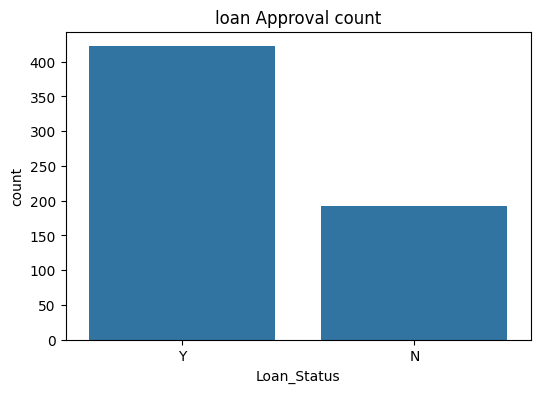

In [429]:
# Categorical variables
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df_train)
plt.title('loan Approval count')
plt.show()

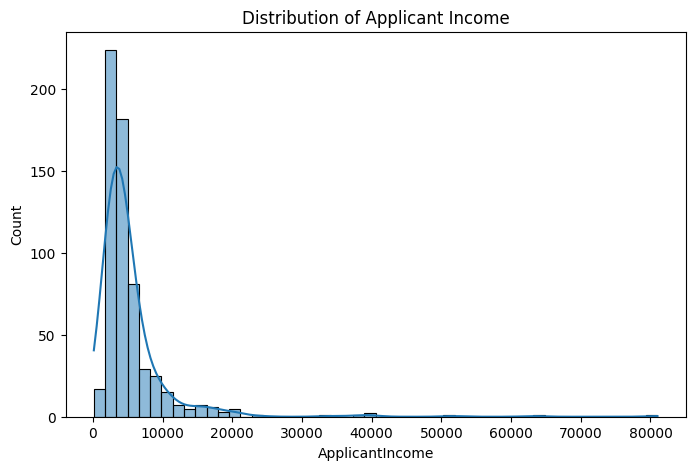

In [430]:
plt.figure(figsize=(8, 5))
sns.histplot(df_train['ApplicantIncome'], bins=50, kde=True)
plt.title('Distribution of Applicant Income')
plt.show()

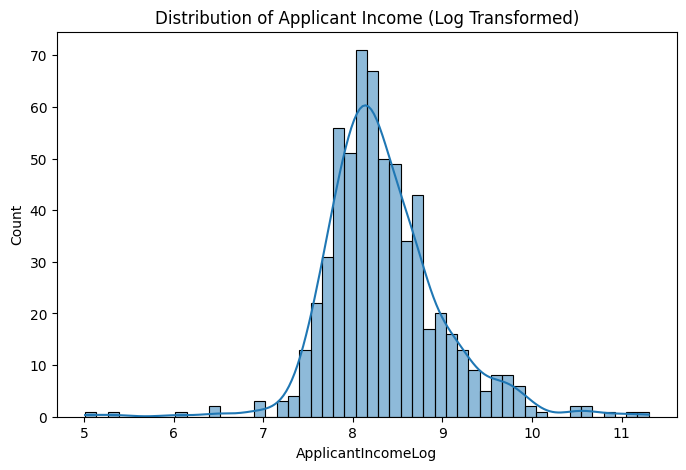

In [431]:
# 1. Apply Log Transformation
df_train['ApplicantIncomeLog'] = np.log(df_train['ApplicantIncome'])

# 2. Plot the new distributions
plt.figure(figsize=(8, 5))
sns.histplot(df_train['ApplicantIncomeLog'], bins=50, kde=True)
plt.title('Distribution of Applicant Income (Log Transformed)')
plt.show()

### **3.2 Bivariate Analysis**

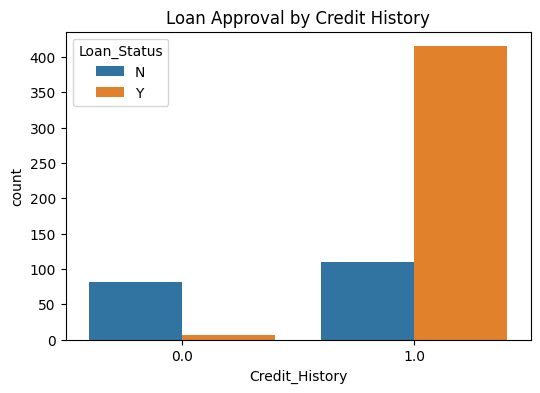

In [432]:
# Creadit_History vs Loan_Status
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df_train)
plt.title('Loan Approval by Credit History')
plt.show()

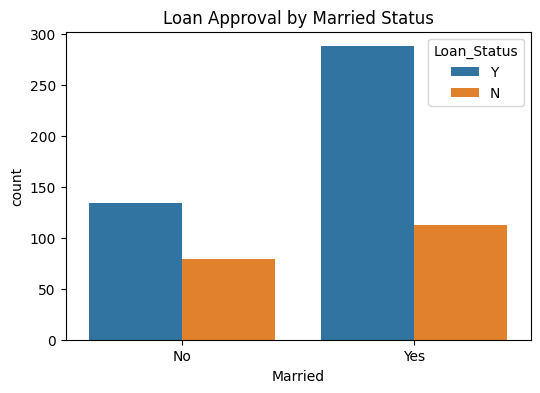

In [433]:
# Married vs Loan_Status
plt.figure(figsize=(6, 4))
sns.countplot(x='Married', hue='Loan_Status', data=df_train)
plt.title('Loan Approval by Married Status')
plt.show()

## **4. Feature Engineer**

In [434]:
# Create a total income column by adding the applicant and coapplicant income
df_train['Total_Income'] = df_train['ApplicantIncome'] + df_train['CoapplicantIncome']

# Apply log tranformation to smooth outliers
df_train['Total_Income'] = np.log(df_train['Total_Income'])

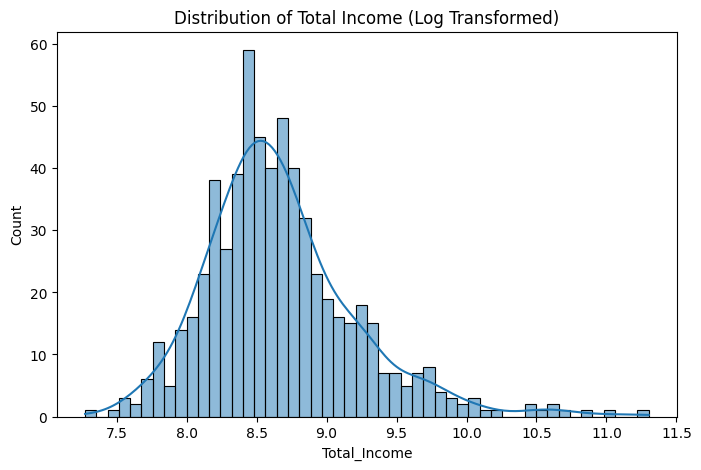

In [435]:
plt.figure(figsize=(8,5))
sns.histplot(df_train['Total_Income'], bins=50, kde=True)
plt.title('Distribution of Total Income (Log Transformed)')
plt.show()

In [436]:
# Drop useless columns
cols_to_drop = ['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome']
df_train = df_train.drop(columns=cols_to_drop)

In [437]:
# Convert categorical variable to dummies/numbers
le = LabelEncoder()

for col in cat_cols:
    df_train[col] = le.fit_transform(df_train[col])

In [438]:
df_train.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncomeLog,Total_Income
0,1,0,0,0,0,128.0,360.0,1.0,2,1,8.674026,8.674026
1,1,1,1,0,0,128.0,360.0,1.0,0,0,8.430109,8.714568
2,1,1,0,0,1,66.0,360.0,1.0,2,1,8.006368,8.006368
3,1,1,0,1,0,120.0,360.0,1.0,2,1,7.856707,8.505323
4,1,0,0,0,0,141.0,360.0,1.0,2,1,8.699515,8.699515


## **5. Machine Learning**

In [439]:
# Define X (Features) and y (Target)
X = df_train.drop(columns=('Loan_Status')) # Everything column expect for the answer for the define problem
y = df_train['Loan_Status']

# Split into train (80%) and test (20%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [440]:
print(X_train.shape)

(491, 11)


In [441]:
print(X_test.shape)

(123, 11)


**Random Forest**

In [442]:
# 1. Initilise model
rf_model = RandomForestClassifier(random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Test teh model
rf_predictions = model.predict(X_test)

# 4. Grade the Exam
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Model Accuracy: {rf_accuracy * 100:.2f}%")

print("\nDetailed Report Card:")
print(classification_report(y_test, rf_predictions))

Random Forest Model Accuracy: 78.05%

Detailed Report Card:
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



**Logistic Regression**

In [443]:
log_model = LogisticRegression(random_state=42, max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_predictions)
print(f"Logistic Regression Model Accuracy: {log_accuracy * 100:.2f}%")

print("\nDetailed Report Card:")
print(classification_report(y_test, log_predictions))


Logistic Regression Model Accuracy: 78.86%

Detailed Report Card:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

